## Testing ensemble parameters

In [251]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import fiona
import shapely.geometry
from pyproj import Geod
from ewatercycle.observation.grdc import get_grdc_data

import hydrostats.metrics as hm



In [252]:


obs = get_grdc_data(2617110,
                   '1900-01-01T00:00Z',
                   '2001-01-01T00:00Z',
                   data_home='/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/')

obs_subset = obs.sel(time=slice("1954-01-02", "1956-12-30"))
obs_series = obs_subset['streamflow'].to_pandas()
print(f"Station Name = {obs.station_name.values} ")

Station Name = KERKI 


In [253]:

HBV_ensemble = pd.read_csv(
    "HBV_GRDC_Kerki_5456_ensemble.csv",
    index_col=0,          # use first column as index
    parse_dates=True      # automatically parse as datetime if possible
)
HBV_ensemble.index = pd.to_datetime(HBV_ensemble.index)
HBV_subset = HBV_ensemble.loc['1954-01-02':'1956-12-30']

print(type(HBV_ensemble))

<class 'pandas.core.frame.DataFrame'>


In [254]:
def catchment_area_from_shapefile(shapefile_path, ellps="WGS84"):
    """
    Compute the area (in m²) of the first polygon in a shapefile.

    Parameters
    ----------
    shapefile_path : str
        Path to the shapefile (.shp)
    ellps : str, optional
        Ellipsoid for area calculation (default: WGS84)

    Returns
    -------
    float
        Absolute area of the polygon in square meters
    """
    # Load polygon
    with fiona.open(shapefile_path) as src:
        poly = shapely.geometry.shape(src[0]["geometry"])

    # Define ellipsoid
    geod = Geod(ellps=ellps)

    # Compute area and perimeter
    area, _ = geod.geometry_area_perimeter(poly)

    return abs(area)

In [255]:
area_chatly = catchment_area_from_shapefile(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/AralSea_Basin/Chatly_GRDC/Chatly_GRDC.shx"
)
area_kerki = catchment_area_from_shapefile(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/AralSea_Basin/GRDC_Kerki/GRDC_Kerki.shx"
)


conversion_mmday2m3s = 1 / (1000 * 86400)

HBV_ensemble = HBV_ensemble *conversion_mmday2m3s *area_kerki
HBV_subset = HBV_subset *conversion_mmday2m3s *area_kerki

In [256]:
import ast

setup_kwargs_lst = []

with open("setup_kwargs_lst_simple_kerki.txt", "r") as f:
    lines = [line.strip() for line in f if line.strip()]  # remove empty lines

i = 0
while i < len(lines):
    if lines[i].startswith("Particle"):
        # next two lines should be parameters and initial_storage
        params_line = lines[i+1].split("parameters: ")[-1]
        storage_line = lines[i+2].split("initial_storage: ")[-1]

        parameters = ast.literal_eval(params_line)
        initial_storage = ast.literal_eval(storage_line)

        setup_kwargs_lst.append({
            'parameters': parameters,
            'initial_storage': initial_storage
        })

        i += 3  # move to next particle
    else:
        i += 1  # skip any unexpected lines

In [257]:
# Create n_particles x 9 array
param_matrix = np.array([p['parameters'] for p in setup_kwargs_lst])
# shape (10, 9)

In [258]:
param_matrix

array([[1.81602056e+00, 9.56631626e-01, 5.66959437e+01, ...,
        1.59473450e-02, 3.36317937e-03, 3.17199321e-01],
       [1.78689429e+01, 9.05434274e-01, 5.50662277e+02, ...,
        1.64853272e-02, 4.40034771e-03, 1.73942730e-01],
       [9.75853290e+00, 9.12676868e-01, 3.98734788e+02, ...,
        1.19398487e-02, 2.86294588e-03, 3.64771376e-01],
       ...,
       [1.54894091e+01, 3.46586653e-01, 7.59743946e+02, ...,
        1.75160795e-02, 6.44779968e-04, 2.23776605e-01],
       [2.13520611e+01, 4.17196126e-01, 3.20422956e+02, ...,
        1.04570980e-02, 4.95646458e-03, 3.60506727e-01],
       [2.48287113e+01, 5.41910779e-01, 3.05682700e+02, ...,
        1.28048287e-02, 7.77520478e-03, 3.39493132e-01]])

In [259]:
def nse(sim, obs):
    return 1 - np.sum((sim - np.mean(obs))**2) / np.sum((sim - obs)**2)

performance = np.array([nse(HBV_subset[col].values, obs_series.values) 
                        for col in HBV_subset.columns])

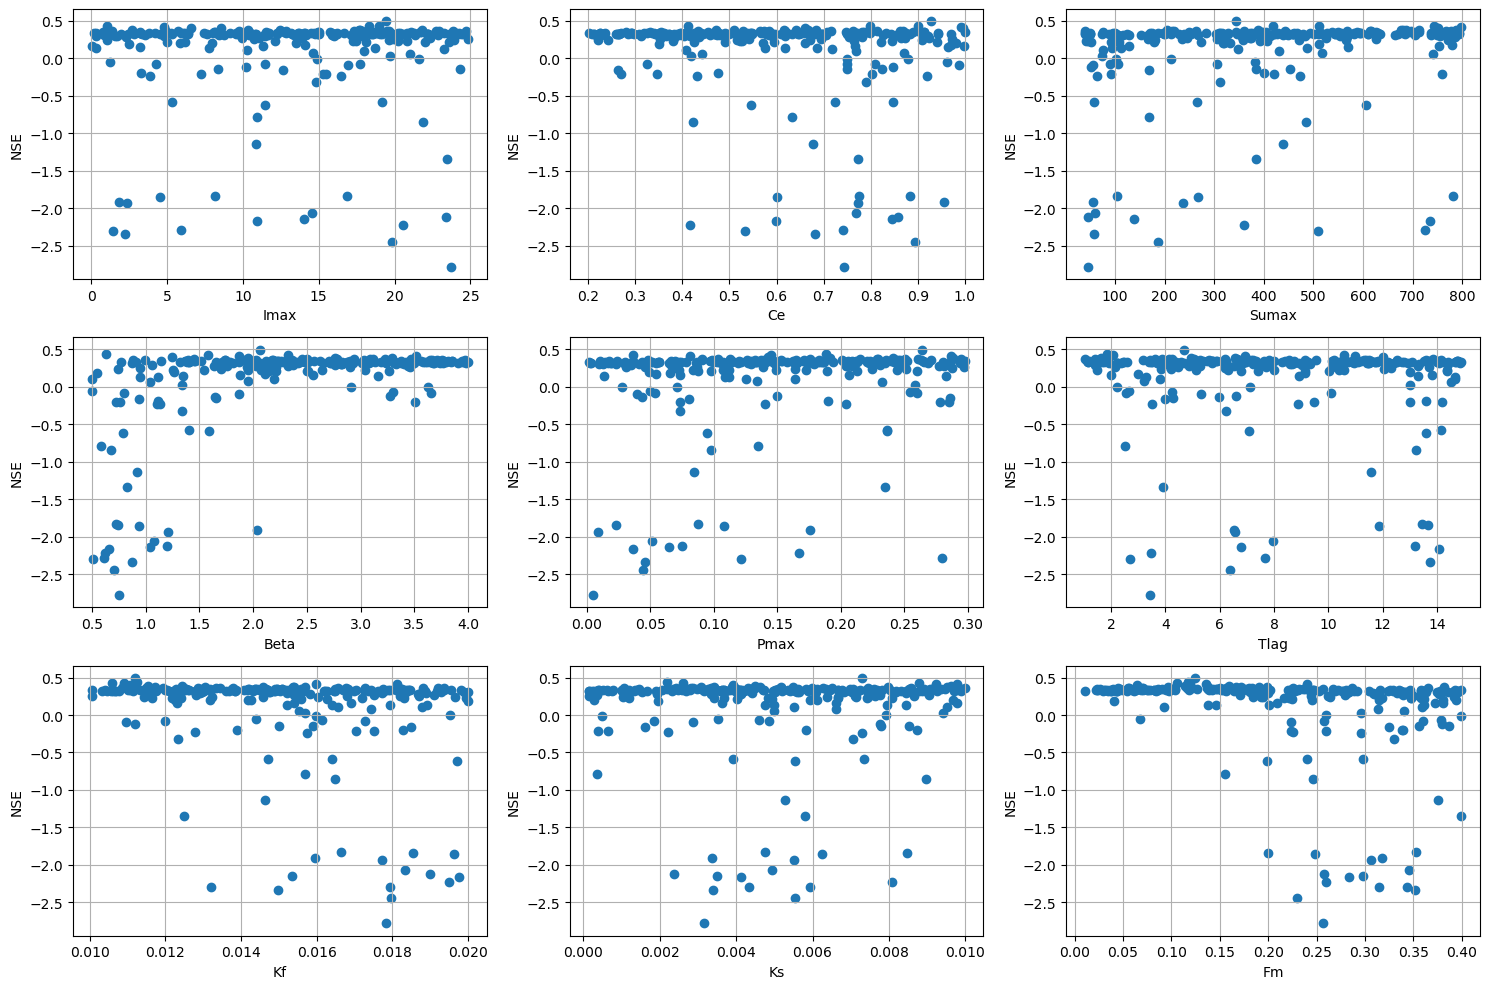

Imax: Spearman correlation = 0.04
Ce: Spearman correlation = -0.09
Sumax: Spearman correlation = 0.33
Beta: Spearman correlation = 0.38
Pmax: Spearman correlation = 0.24
Tlag: Spearman correlation = -0.11
Kf: Spearman correlation = -0.29
Ks: Spearman correlation = 0.02
Fm: Spearman correlation = -0.52


In [260]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

param_matrix = np.array([p['parameters'] for p in setup_kwargs_lst])
param_names = ["Imax","Ce","Sumax","Beta","Pmax","Tlag","Kf","Ks","Fm"]

# Scatter plots
fig, axes = plt.subplots(3, 3, figsize=(15,10))
axes = axes.flatten()

for i, name in enumerate(param_names):
    axes[i].scatter(param_matrix[:, i], performance)
    axes[i].set_xlabel(name)
    axes[i].set_ylabel("NSE")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

# Spearman correlations
for i, name in enumerate(param_names):
    corr, _ = spearmanr(param_matrix[:, i], performance)
    print(f"{name}: Spearman correlation = {corr:.2f}")


In [261]:
aligned = pd.concat([HBV_subset, obs_series], axis=1)
aligned.columns = list(HBV_subset.columns) + ["obs"]

# Drop rows with ANY NaN
aligned_clean = aligned.dropna()

In [262]:
aligned_clean_subset = aligned_clean.loc['1955-01-02':'1956-12-30']

In [263]:
aligned_clean_subset

,particle 0,particle 1,particle 2,particle 3,particle 4,particle 5,particle 6,particle 7,particle 8,particle 9,...,particle 241,particle 242,particle 243,particle 244,particle 245,particle 246,particle 247,particle 248,particle 249,obs
1955-01-02,481.031013,222.366028,409.845388,412.246224,247.324272,34.053556,418.194248,327.819033,229.084843,119.426083,...,75.098767,164.778251,209.706433,145.330780,223.407741,109.191297,389.629168,326.602839,249.888695,916.0
1955-01-03,475.572250,219.049535,407.382890,405.182414,245.546442,33.780562,415.435367,324.516012,227.008642,118.900824,...,74.907547,163.321060,208.304918,143.618177,221.216487,108.683788,383.425649,323.739457,246.990561,905.0
1955-01-04,470.193375,215.786972,404.948405,398.243611,243.792894,33.511377,412.703968,321.250912,224.959783,118.379616,...,74.716404,161.879227,206.927055,141.926339,219.059400,108.184893,377.331109,320.904124,244.128335,899.0
1955-01-05,464.893158,212.577454,402.541602,391.427585,242.063242,33.245936,409.999772,318.023291,222.937911,117.862393,...,74.525265,160.452444,205.572391,140.255016,216.935930,107.694455,371.343640,318.096557,241.301549,893.0
1955-01-06,459.670346,209.420110,400.162149,384.732150,240.357088,32.984176,407.322497,314.832695,220.942671,117.349095,...,74.334118,159.040436,204.240480,138.603956,214.845537,107.212321,365.461364,315.316474,238.509743,890.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1956-12-26,426.456051,239.481991,419.687000,374.602265,207.585586,12.396271,477.553951,262.428428,246.348937,109.638345,...,51.786374,109.986979,190.889844,99.299820,259.569464,97.013905,397.726971,242.726142,181.728124,811.0
1956-12-27,421.455844,235.752556,417.529056,367.981589,206.180513,12.296950,474.165487,259.695555,244.638841,109.212673,...,51.677290,109.031355,189.636266,98.095771,256.810748,96.634162,391.798970,240.574634,179.609167,792.0
1956-12-28,416.529599,232.084421,415.393526,361.478741,204.793853,12.199190,470.811130,256.995259,242.950571,108.790076,...,51.568058,108.085710,188.403752,96.906667,254.095139,96.260386,385.974761,238.444320,177.516585,772.0
1956-12-29,411.676135,228.476576,413.280155,355.091620,203.425286,12.102964,467.490524,254.327148,241.283841,108.370476,...,51.458628,107.149777,187.191876,95.732317,251.421935,95.892475,380.252525,236.334984,175.450026,772.0


In [264]:
# def nse(sim, obs):
#     sim = np.asarray(sim)
#     obs = np.asarray(obs)

#     denom = np.sum((obs - obs.mean())**2)
#     if denom == 0:
#         return np.nan
#     return 1 - np.sum((sim - obs)**2) / denom

def calc_NSE(Qm, Qo):
    QoAv  = np.mean(Qo)
    ErrUp = np.sum((Qm - Qo)**2)
    ErrDo = np.sum((Qo - QoAv)**2)
    return 1 - (ErrUp / ErrDo)



In [265]:
# performance = np.array([
#     calc_NSE(aligned_clean_subset[col].values, aligned_clean_subset["obs"].values)
#     for col in HBV_subset.columns
# ])


performance = np.array([
    hm.kge_2012(aligned_clean_subset[col].values, aligned_clean_subset["obs"].values)
    for col in HBV_subset.columns
])

name_function = hm.kge_2012.name
name_abbr = hm.kge_2012.abbr

In [266]:
print(name_abbr)

KGE (2012)


In [267]:
print(performance)
print("Any NaN left?", np.isnan(performance).any())


[ 6.44714732e-01  1.13036974e-01  1.98655535e-01  5.99739504e-01
  1.08711584e-01 -1.25888177e-01 -3.85627181e-02  3.36715115e-01
  1.47405379e-01 -3.43863551e-01 -6.28371780e-01  1.34771911e-01
  3.63236309e-01  5.48343489e-01  5.36907730e-01 -3.33717204e-02
  2.68001393e-02  4.42825840e-02  3.07270952e-01  1.42244592e-01
  9.66700459e-02  9.80044536e-02  5.19356373e-01  7.32969713e-02
  6.26896100e-01  3.98915484e-01 -3.03056044e-01  3.88628387e-01
 -1.70293413e-01 -3.75405799e-02 -6.04207551e-02  5.66440084e-01
  6.53127237e-02 -1.88003744e-02  3.81665698e-01  1.24791214e-01
  4.46848084e-01 -1.79935385e-01  4.13924099e-02 -3.97423570e-02
 -2.45002460e-01 -7.86917654e-02 -3.98206387e-03  2.96754975e-01
 -1.58909861e-02 -4.33370668e-01  9.28096093e-02 -4.79123386e-01
 -3.90403064e-02  7.86997176e-01  4.35137912e-02 -7.28508996e-01
  1.88523653e-01  2.96507832e-01  9.57898128e-02  3.46156107e-01
  1.18267466e-01  4.48809895e-01  6.05297591e-01 -1.59105612e-01
  3.53951773e-01 -6.18304

Text(0.5, 1.0, 'Ensemble spread (per day)')

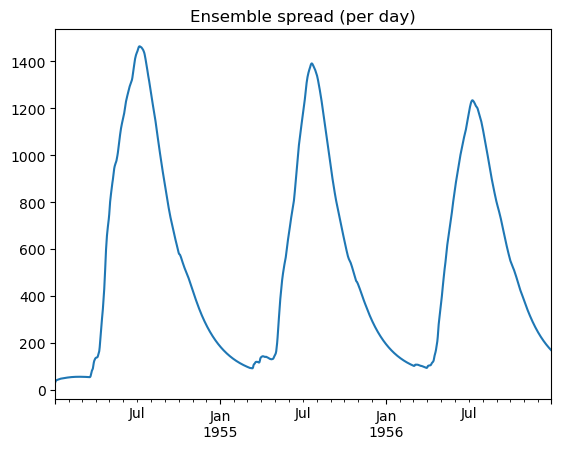

In [268]:
HBV_subset.std(axis=1).plot()
plt.title("Ensemble spread (per day)")

In [269]:
from scipy.stats import spearmanr

for i, name in enumerate(param_names):
    rho, p = spearmanr(param_matrix[:, i], performance)
    print(f"{name}: ρ={rho:.3f}, p={p:.3f}")

Imax: ρ=-0.076, p=0.231
Ce: ρ=0.408, p=0.000
Sumax: ρ=-0.215, p=0.001
Beta: ρ=-0.591, p=0.000
Pmax: ρ=-0.090, p=0.155
Tlag: ρ=0.097, p=0.126
Kf: ρ=0.141, p=0.026
Ks: ρ=0.060, p=0.347
Fm: ρ=0.520, p=0.000


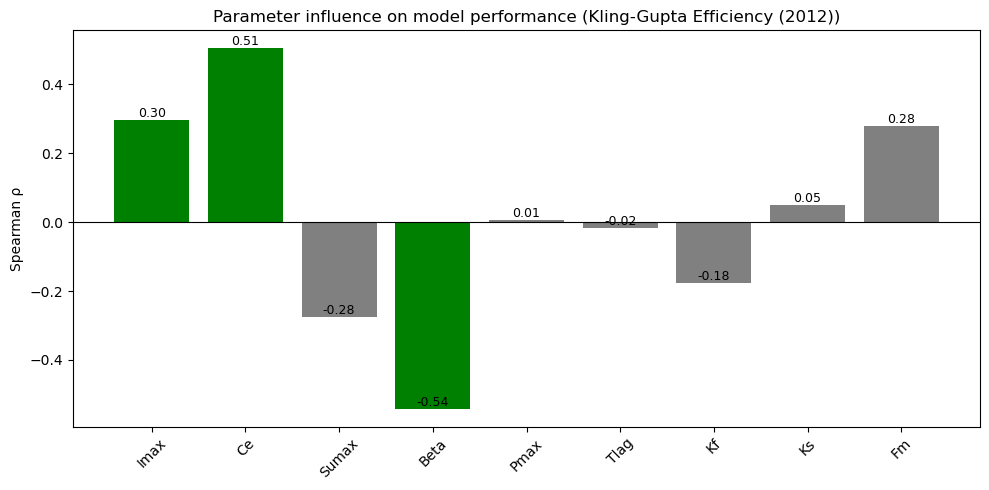

In [270]:
import matplotlib.pyplot as plt
import numpy as np

# Your data
param_names = ["Imax","Ce","Sumax","Beta","Pmax","Tlag","Kf","Ks","Fm"]
rho_values = [0.296, 0.505, -0.276, -0.541, 0.006, -0.017, -0.177, 0.050, 0.279]
p_values = [0.037, 0.000, 0.052, 0.000, 0.969, 0.908, 0.218, 0.729, 0.050]

# Set colors: significant p < 0.05
colors = ['green' if p < 0.05 else 'gray' for p in p_values]

# Plot
plt.figure(figsize=(10,5))
bars = plt.bar(param_names, rho_values, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel("Spearman ρ")
plt.title(f"Parameter influence on model performance ({name_function})")
plt.xticks(rotation=45)

# Optional: add ρ value labels on top of bars
for bar, rho in zip(bars, rho_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{rho:.2f}",
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


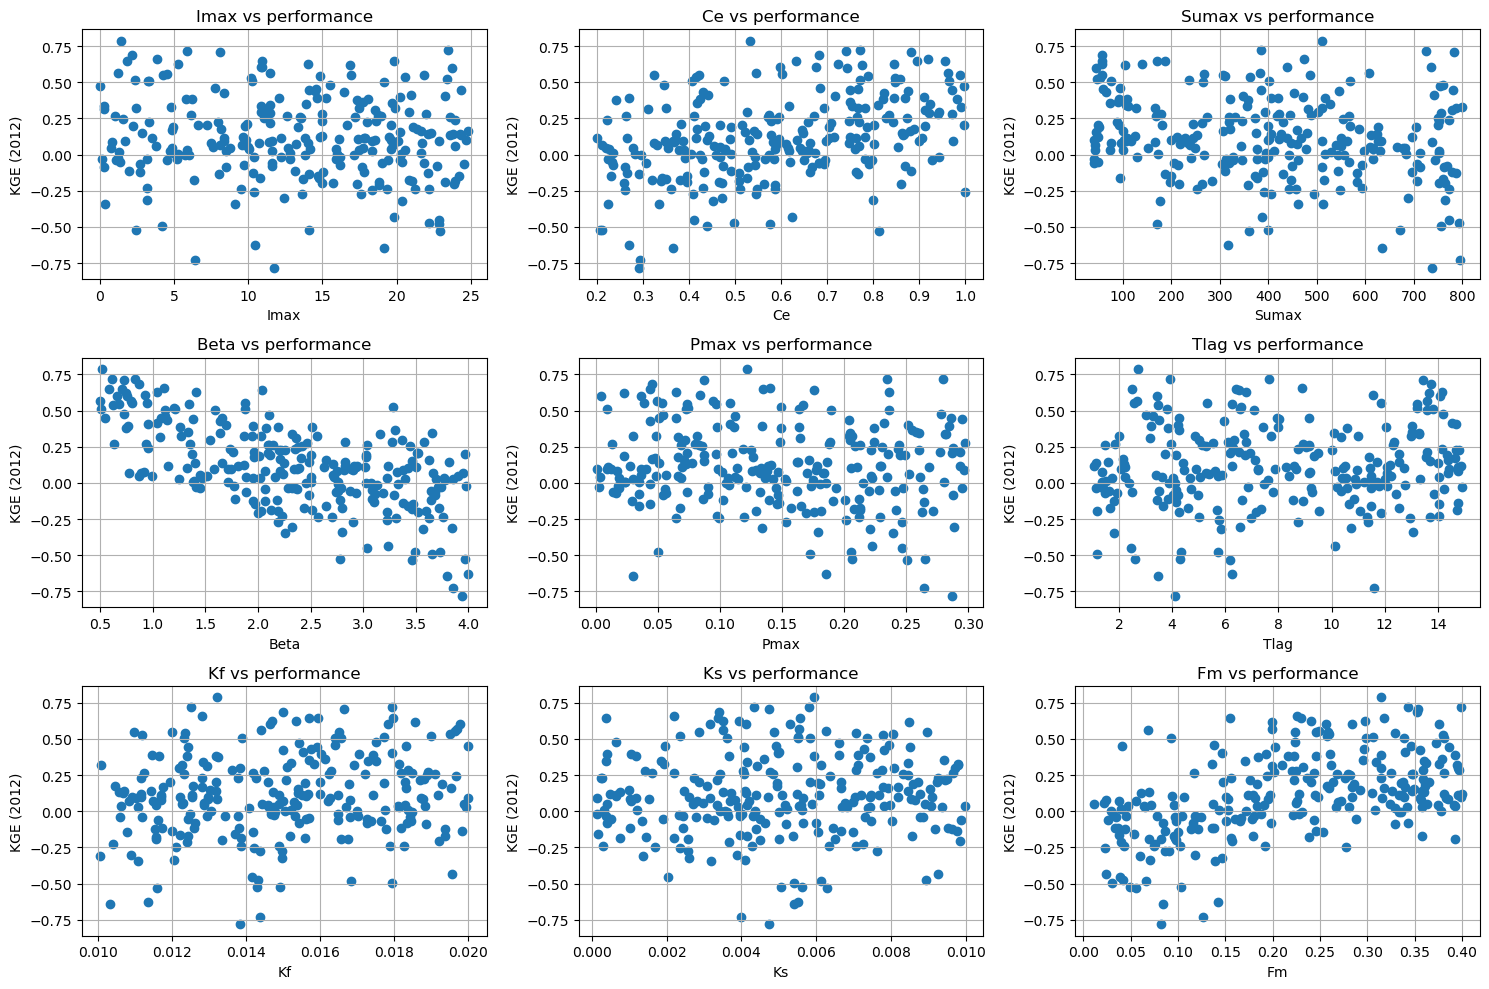

Imax: Spearman correlation = -0.08
Ce: Spearman correlation = 0.41
Sumax: Spearman correlation = -0.21
Beta: Spearman correlation = -0.59
Pmax: Spearman correlation = -0.09
Tlag: Spearman correlation = 0.10
Kf: Spearman correlation = 0.14
Ks: Spearman correlation = 0.06
Fm: Spearman correlation = 0.52


In [271]:
fig, axes = plt.subplots(3, 3, figsize=(15,10))
axes = axes.flatten()

for i, name in enumerate(param_names):
    axes[i].scatter(param_matrix[:, i], performance)
    axes[i].set_xlabel(name)
    axes[i].set_ylabel(f"{name_abbr}")
    axes[i].set_title(f"{name} vs performance")  # <-- fixed
    axes[i].grid(True)




# for i, name in enumerate(param_names):
#     axes[i].scatter(param_matrix[:, i], performance)
#     axes[i].set_xlabel(name)
#     axes[i].set_ylabel("NSE")
#     axes[i].grid(True)

plt.tight_layout()
plt.show()

# Spearman correlations
for i, name in enumerate(param_names):
    corr, _ = spearmanr(param_matrix[:, i], performance)
    print(f"{name}: Spearman correlation = {corr:.2f}")

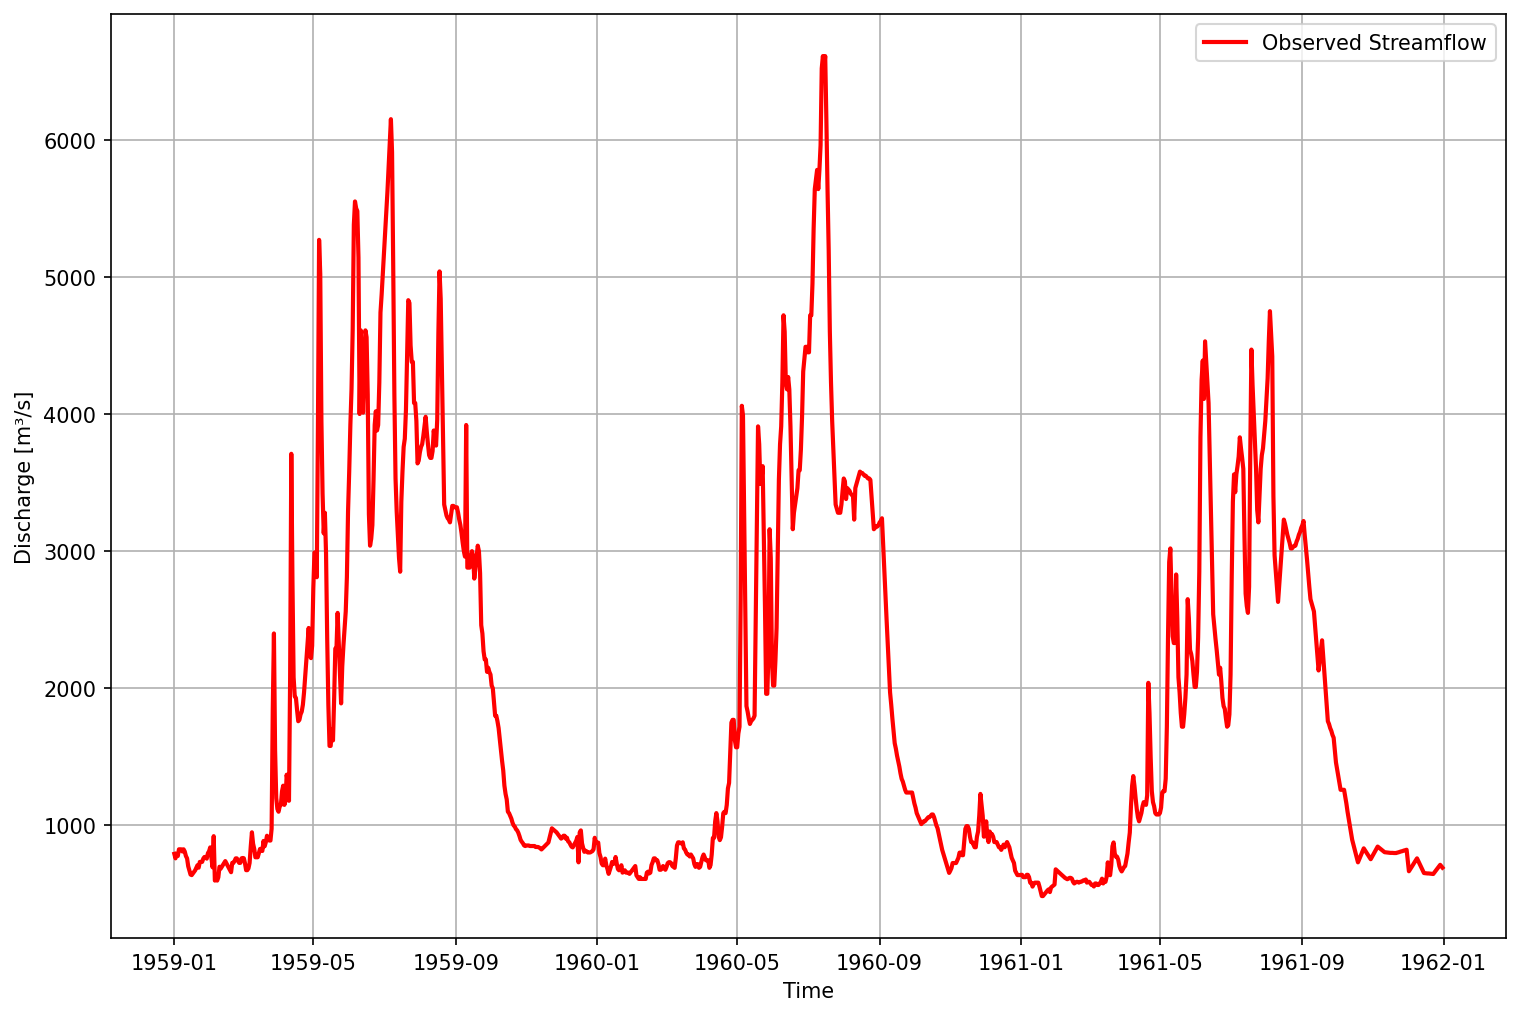

In [272]:
# Make sure the index is datetime
#HBV_ensemble.index = pd.to_datetime(HBV_ensemble.index)

# Select rows in 1960
subset = HBV_subset.loc['1959' :'1961']


# fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

# # Plot HBV ensemble members
# ax = subset.plot(color = 'black' ,alpha = 0.1)  # plot all lines
# ax.get_legend().remove()  # remove the legend entirely

# # Plot observed streamflow with a label
# obs['streamflow'].sel(time=slice("1959-01-01","1961-12-31")).plot(
#     ax=plt.gca(), color='r', linewidth=2, label='Observed Streamflow'
# )

# plt.xlabel('Time')
# plt.ylabel('Discharge [m³/s]')
# plt.grid()
# #plt.ylim(0,2000)
# #plt.legend(False)
# plt.show()

fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

# Plot each ensemble member without creating legend labels
for col in subset.columns:
    ax.plot(subset.index, subset[col], color='black', alpha=0.1, label='_nolegend_')

# Plot observed streamflow
obs_series = obs['streamflow'].sel(time=slice("1959-01-01","1961-12-31"))
ax.plot(obs_series['time'], obs_series.values, color='r', linewidth=2, label='Observed Streamflow')

ax.set_xlabel('Time')
ax.set_ylabel('Discharge [m³/s]')
ax.grid(True)
ax.legend()  # Only shows the observed line
plt.show()



In [273]:
print(type(subset))

<class 'pandas.core.frame.DataFrame'>


In [274]:
# Get indices of top 5 performance values
top_indices = np.argsort(performance)[-5:][::-1]  # descending order

# Select the corresponding parameter sets
top_params = param_matrix[top_indices]

# Corresponding performance values
top_performance = performance[top_indices]

# Display
for i, idx in enumerate(top_indices):
    print(f"Rank {i+1}: Performance={performance[idx]:.3f}, Parameters={param_matrix[idx]}")

Rank 1: Performance=0.787, Parameters=[1.45197413e+00 5.32414158e-01 5.10051426e+02 5.13793028e-01
 1.21618379e-01 2.70619668e+00 1.31961887e-02 5.94101978e-03
 3.14826427e-01]
Rank 2: Performance=0.721, Parameters=[2.34408876e+01 7.72457355e-01 3.84751571e+02 8.29645717e-01
 2.34757912e-01 3.90904124e+00 1.24953945e-02 5.79851346e-03
 3.98956798e-01]
Rank 3: Performance=0.719, Parameters=[5.89030557e+00 7.42139797e-01 7.24737276e+02 6.09740443e-01
 2.79911912e-01 7.65496614e+00 1.79407519e-02 4.34149274e-03
 3.43103571e-01]
Rank 4: Performance=0.708, Parameters=[8.12777045e+00 8.83232181e-01 7.82176711e+02 7.23998160e-01
 8.76308349e-02 1.34595321e+01 1.66448055e-02 4.74308810e-03
 3.53104120e-01]
Rank 5: Performance=0.685, Parameters=[2.19667643e+00 6.81691417e-01 5.79633622e+01 8.71801252e-01
 4.56079025e-02 1.37616877e+01 1.49911350e-02 3.39312776e-03
 3.51892117e-01]


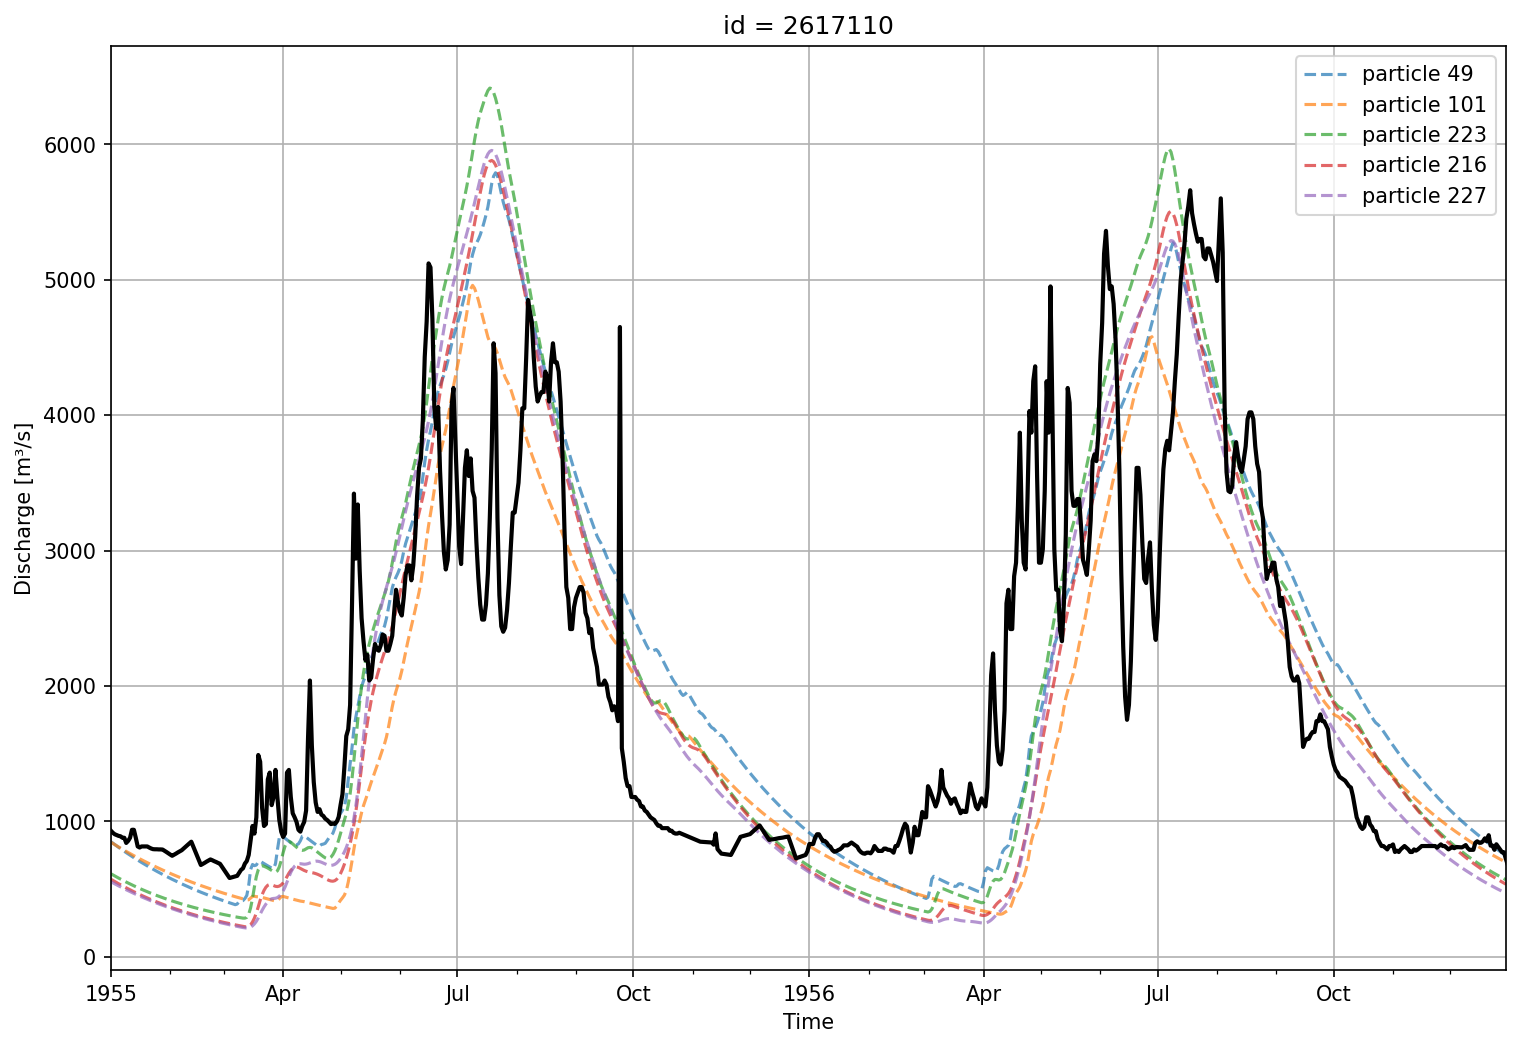

In [275]:
subset_top = HBV_subset.iloc[:, top_indices]  # select only these columns

fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

# Plot ensemble members on the existing axes
subset_top.loc['1955':'1956'].plot(ax=ax, linestyle ='--', alpha=0.7)
#ax.get_legend().remove()

# Plot observed streamflow
obs['streamflow'].sel(time=slice("1955-01-01", "1956-12-31")).plot(
    ax=ax, color='k', linewidth=2, label='Observed Streamflow'
)

ax.set_xlabel('Time')
ax.set_ylabel('Discharge [m³/s]')
ax.grid()
plt.show()